# 51 Ridge Regression — RidgeCV

Modelos Ridge para `sale` y `rent` prediciendo `log_precio`.

**Pipeline:**
1. Eliminación de outliers en `log_precio` con método IQR antes del split
2. Agrupación de municipios con < 10 registros en `municipio_otros`
3. Manejo de `es_exterior` y `tiene_ascensor`: renombradas a `es_exterior_piso` y `tiene_ascensor_piso`
4. Exclusiones:
   - `log_precio` → es el target
   - `precio_m2` → leakage
   - `tipologia` → categórica cruda (se usan las dummies `tipologia_unificada_*`)
5. Split 80/20 train/test
6. Estandarización con `StandardScaler` (Ridge es sensible a la escala)
7. **RidgeCV** sobre train (CV=5, 200 alphas log-espaciados) para selección del parámetro de regularización
8. Ajuste final con `Ridge(alpha=alpha_opt)`
9. Validación cruzada 5-fold (CV=5): MSE, RMSE, MAE, MAPE y R²
10. VIF para diagnóstico de multicolinealidad (sobre features originales, no estandarizadas)
11. Coeficientes estandarizados ordenados por magnitud absoluta  
    *(Ridge no anula coeficientes: todos los regresores permanecen en el modelo)*
12. Gráficos diagnósticos: Real vs Predicho, residuos, histograma residuos

**Nota sobre p-values:** Ridge no es un estimador de mínimos cuadrados ordinarios, por lo que
los p-values clásicos no están definidos. En su lugar se muestran los coeficientes estandarizados
como medida de importancia relativa.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import KFold, cross_val_predict, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

# ── Configuración global ──────────────────────────────────────────────────────
RANDOM_STATE             = 42
TEST_SIZE                = 0.20
N_SPLITS                 = 5
TARGET_COL               = "log_precio"
IQR_FACTOR               = 1.5
MIN_MUNICIPIO_REGISTROS  = 10

# Alphas candidatos para RidgeCV: rango amplio log-espaciado
RIDGE_ALPHAS = np.logspace(-3, 5, 200)

# ── Features candidatas (idénticas al notebook LassoCV) ──────────────────────
# Ridge no elimina features, pero usa el mismo espacio de partida para
# comparabilidad directa con los otros dos notebooks.
CANDIDATE_FEATURES = [
    "superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    "latitud",
    "longitud",
    "planta",
    "es_exterior",       # → renombrado a es_exterior_piso
    "tiene_ascensor",    # → renombrado a tiene_ascensor_piso
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    "log_superficie_construida_m2",
    "precio_m2_municipio_media",
    "ratio_dormitorios_superficie",
    "ratio_banos_superficie",
    "habitaciones",
    "ratio_habitaciones_superficie",
    "interaccion_superficie_banos",
    "interaccion_superficie_habitaciones",
    "planta_num",
    "interaccion_planta_sin_ascensor_piso",
    "latitud_2",
    "longitud_2",
    "interaccion_latitud_longitud",
    "distancia_centro_municipio_km",
    "score_cercania_servicios",
    "superficie_construida_m2_2",
    "numero_banos_2",
    "numero_dormitorios_2",
    "habitaciones_2",
    "tipologia_unificada_piso",
    "tipologia_unificada_unifamiliar",
    # municipio_* se añaden dinámicamente tras agrupar pequeños municipios
]

# ── Rutas de datos ────────────────────────────────────────────────────────────
def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "data" / "gold").exists():
            return candidate
    raise FileNotFoundError("No se encontro la raiz del proyecto con data/gold")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATASETS = {
    "sale": PROJECT_ROOT / "data" / "gold" / "final_sale.csv",
    "rent": PROJECT_ROOT / "data" / "gold" / "final_rent.csv",
}

for name, path in DATASETS.items():
    if not path.exists():
        raise FileNotFoundError(f"No se encontro {name}: {path}")

print("Datasets listos:")
for name, path in DATASETS.items():
    print(f"  {name}: {path}")

Datasets listos:
  sale: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_sale.csv
  rent: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_rent.csv


In [2]:
# ── Funciones auxiliares ──────────────────────────────────────────────────────

def remove_outliers_iqr(df: pd.DataFrame, col: str = TARGET_COL) -> pd.DataFrame:
    """Elimina outliers en `col` con método IQR antes del split."""
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr    = q3 - q1
    lower  = q1 - IQR_FACTOR * iqr
    upper  = q3 + IQR_FACTOR * iqr
    mask   = df[col].between(lower, upper)
    n_out  = (~mask).sum()
    print(f"  Rango válido [{col}]: [{lower:.4f}, {upper:.4f}]")
    print(f"  Outliers eliminados: {n_out} / {len(df)} ({n_out / len(df) * 100:.1f}%)")
    return df[mask].copy()


def group_small_municipios(df: pd.DataFrame) -> tuple:
    mun_cols   = [c for c in df.columns if c.startswith("municipio_")]
    if not mun_cols:
        return df, []
    mun_counts = df[mun_cols].sum()
    small_muns = mun_counts[mun_counts < MIN_MUNICIPIO_REGISTROS].index.tolist()
    big_muns   = mun_counts[mun_counts >= MIN_MUNICIPIO_REGISTROS].index.tolist()
    nombres_small = sorted([m.replace("municipio_", "") for m in small_muns])
    nombres_big   = sorted([m.replace("municipio_", "") for m in big_muns])
    print(f"  Municipios agrupados en 'otros' (< {MIN_MUNICIPIO_REGISTROS} registros, n={len(small_muns)}): {nombres_small}")
    print(f"  Municipios mantenidos (n={len(big_muns)}): {nombres_big}")
    df = df.copy()
    if small_muns:
        df["municipio_otros"] = df[small_muns].max(axis=1)
        df = df.drop(columns=small_muns)
    final_mun_cols = sorted([c for c in df.columns if c.startswith("municipio_")])
    return df, final_mun_cols


def build_feature_matrix(df: pd.DataFrame) -> tuple:
    df, mun_cols = group_small_municipios(df)
    rename_map = {}
    if "es_exterior" in df.columns:
        df["es_exterior_piso"] = df["es_exterior"]
        rename_map["es_exterior"] = "es_exterior_piso"
    if "tiene_ascensor" in df.columns:
        df["tiene_ascensor_piso"] = df["tiene_ascensor"]
        rename_map["tiene_ascensor"] = "tiene_ascensor_piso"
    base_feats = []
    for f in CANDIDATE_FEATURES:
        mapped = rename_map.get(f, f)
        if mapped in df.columns and mapped not in base_feats:
            base_feats.append(mapped)
    all_feats = base_feats + [m for m in mun_cols if m not in base_feats]
    all_feats = [f for f in all_feats if f in df.columns]
    return df, df[all_feats].copy()


def compute_metrics(y_true, y_pred, n_features: int) -> dict:
    mse   = mean_squared_error(y_true, y_pred)
    r2    = r2_score(y_true, y_pred)
    n     = len(y_true)
    r2_adj = (
        1 - (1 - r2) * (n - 1) / (n - n_features - 1)
        if n > n_features + 1 else np.nan
    )
    return {
        "MSE":         float(mse),
        "RMSE":        float(np.sqrt(mse)),
        "MAE":         float(mean_absolute_error(y_true, y_pred)),
        "MAPE":        float(mean_absolute_percentage_error(y_true, y_pred)),
        "R2":          float(r2),
        "R2_ajustado": float(r2_adj),
    }


def compute_vif(X: pd.DataFrame) -> pd.DataFrame:
    """VIF sobre features originales (no estandarizadas). VIF es invariante a la escala."""
    Xc  = sm.add_constant(X.astype(float))
    vif = pd.DataFrame({
        "feature": Xc.columns,
        "VIF":     [variance_inflation_factor(Xc.values.astype(float), i)
                    for i in range(Xc.shape[1])],
    })
    return (
        vif[vif["feature"] != "const"]
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )


def cv_ridge_metrics(X: pd.DataFrame, y: pd.Series, alpha: float, n_features: int) -> dict:
    """Validación cruzada 5-fold con Ridge (estandarizado dentro de cada fold)."""
    kf           = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    fold_results = []
    for tr_idx, val_idx in kf.split(X):
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("ridge",  Ridge(alpha=alpha)),
        ])
        pipe.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        pred = pipe.predict(X.iloc[val_idx])
        fold_results.append(compute_metrics(y.iloc[val_idx], pred, n_features))
    return {k: float(np.mean([m[k] for m in fold_results])) for k in fold_results[0]}


def print_coef_summary(feature_names, coef_std, scaler) -> None:
    """
    Muestra los coeficientes Ridge en dos escalas:
      - coef_std   : coeficiente sobre features estandarizadas (importancia relativa)
      - coef_orig  : coeficiente sobre escala original (coef_std / std_feature)
    """
    coef_df = pd.DataFrame({
        "feature":   feature_names,
        "coef_std":  coef_std,
        "coef_orig": coef_std / scaler.scale_,
    })
    coef_df["|coef_std|"] = coef_df["coef_std"].abs()
    coef_df = coef_df.sort_values("|coef_std|", ascending=False).drop(columns="|coef_std|")
    print(coef_df.round(5).to_string(index=False))


print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.



DATASET: SALE

Filas originales: 588
Detectando outliers en el target:
  Rango válido [log_precio]: [10.9828, 13.8581]
  Outliers eliminados: 6 / 588 (1.0%)
Filas tras limpieza: 582

── Ingeniería de features ──────────────────────────────────────────
  Municipios agrupados en 'otros' (< 10 registros, n=45): ['Ajo', 'Alfoz de Lloredo', 'Ampuero', 'Arcentales', 'Argoños', 'Arnuero', 'Barcena de Cicero', 'Beranga', 'Cartes', 'Castañeda', 'Colindres', 'Cudon', 'El Astillero', 'Entrambasaguas', 'Escalante', 'Galdames', 'Gallarta', 'Getxo', 'Guarnizo', 'Guriezo', 'Hazas de Cesto', 'Heras', 'Isla', 'Liendo', 'Limpias', 'Marina de Cudeyo', 'Medio Cudeyo', 'Meruelo', 'Miengo', 'Mogro', 'Muskiz', 'Penagos', 'Puente San Miguel', 'Ramales de la Victoria', 'Reocin', 'Ribamontan al Mar', 'Ribamontan al Monte', 'Santa Maria de Cayon', 'Santillana del Mar', 'Solares', 'Solorzano', 'Sopuerta', 'Vargas', 'Villapresente', 'Zierbena']
  Municipios mantenidos (n=14): ['Camargo', 'Castro-Urdiales', 'Lared

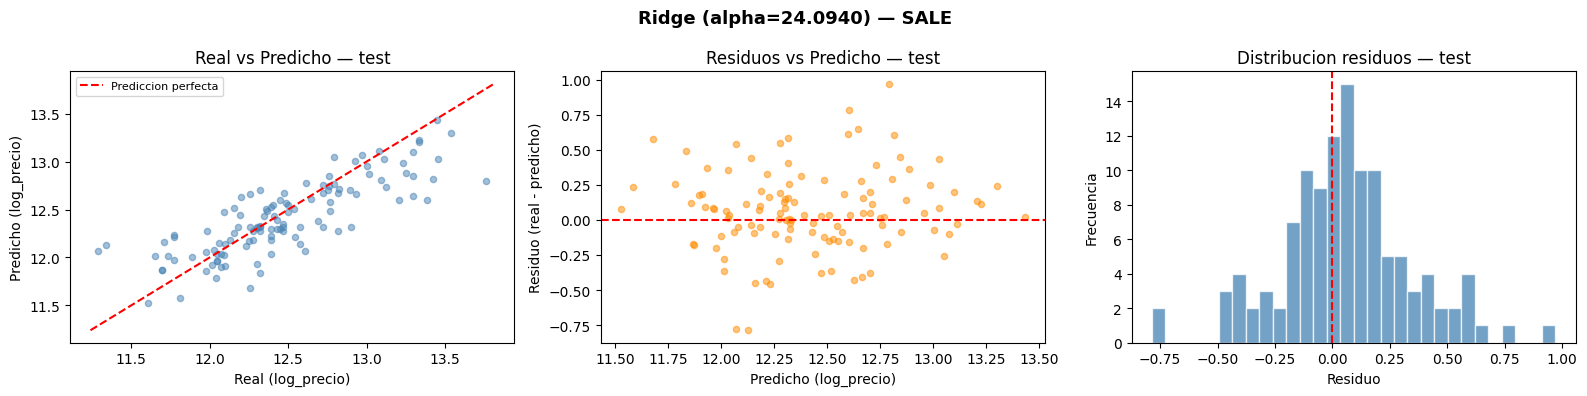


DATASET: RENT

Filas originales: 477
Detectando outliers en el target:
  Rango válido [log_precio]: [6.1079, 7.8074]
  Outliers eliminados: 26 / 477 (5.5%)
Filas tras limpieza: 451

── Ingeniería de features ──────────────────────────────────────────
  Municipios agrupados en 'otros' (< 10 registros, n=30): ['Ampuero', 'Barcena de Cicero', 'Cartes', 'Colindres', 'Cudon', 'Entrambasaguas', 'Gallarta', 'Getxo', 'Guarnizo', 'Guriezo', 'Liendo', 'Limpias', 'Marina de Cudeyo', 'Miengo', 'Noja', 'Polanco', 'Ramales de la Victoria', 'Reocin', 'Ribamontan al Mar', 'Santa Maria de Cayon', 'Santillana del Mar', 'Santoña', 'Santurtzi', 'Sobremazas', 'Solares', 'Suances', 'Villaescusa', 'Villapresente', 'Viveda', 'Voto']
  Municipios mantenidos (n=8): ['Camargo', 'Castro-Urdiales', 'El Astillero', 'Laredo', 'Piélagos', 'Santa Cruz de Bezana', 'Santander', 'Torrelavega']

NaN por feature (imputando con mediana):
planta    92
dtype: int64

Features candidatas (43):
['superficie_construida_m2', 'num

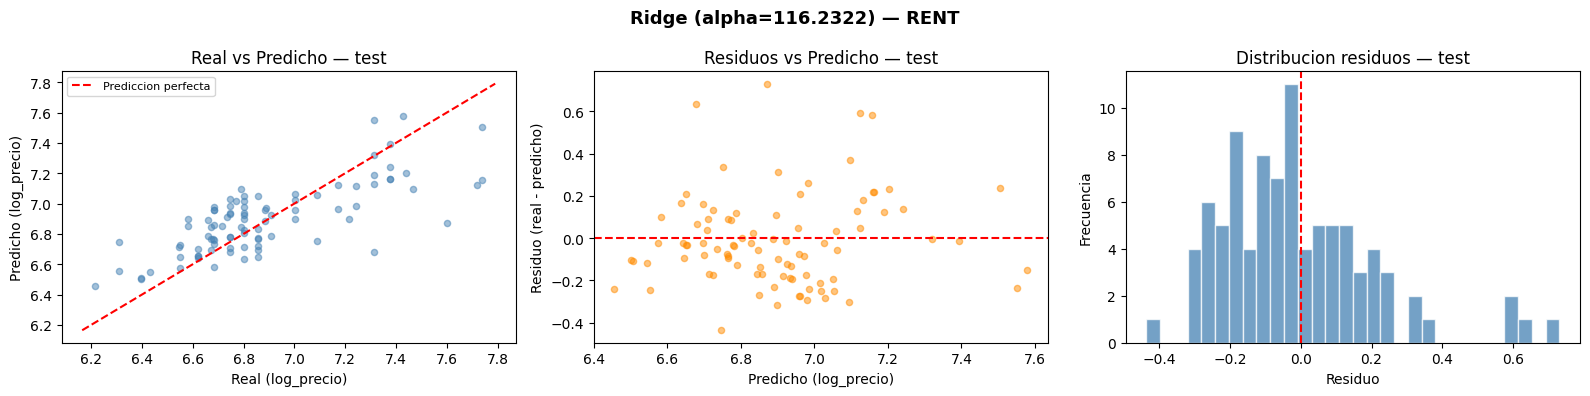


RESUMEN GLOBAL — Ridge RidgeCV
dataset  n_filas  n_features  alpha_ridge  train_RMSE  train_R2  train_R2_adj  CV_5f_RMSE  CV_5f_R2  test_RMSE  test_R2  test_MAE  test_MAPE  delta_RMSE  delta_R2
   sale      582          49     24.09404     0.29490   0.71185       0.67783     0.31850   0.64697    0.29540  0.64864   0.21936    0.01754     0.00050   0.06321
   rent      451          43    116.23225     0.20164   0.55179       0.49080     0.21267   0.51357    0.21731  0.55955   0.16663    0.02395     0.01567  -0.00776


,dataset,n_filas,n_features,alpha_ridge,train_RMSE,train_R2,train_R2_adj,CV_5f_RMSE,CV_5f_R2,test_RMSE,test_R2,test_MAE,test_MAPE,delta_RMSE,delta_R2
0,sale,582,49,24.094036,0.294897,0.711854,0.677832,0.318503,0.646970,0.295402,0.648640,0.219356,0.017541,0.000505,0.063214
1,rent,451,43,116.232247,0.201644,0.551792,0.490802,0.212675,0.513575,0.217315,0.559547,0.166626,0.023948,0.015671,-0.007755


In [3]:
all_summary_rows = []

for dataset_name, dataset_path in DATASETS.items():
    print()
    print("=" * 100)
    print(f"DATASET: {dataset_name.upper()}")
    print("=" * 100)

    # ── Carga y limpieza ──────────────────────────────────────────────────────
    df = pd.read_csv(dataset_path)
    df = df[df[TARGET_COL].notna()].copy()
    print(f"\nFilas originales: {len(df)}")

    print("Detectando outliers en el target:")
    df = remove_outliers_iqr(df)
    print(f"Filas tras limpieza: {len(df)}")

    # ── Ingeniería de features ────────────────────────────────────────────────
    print("\n── Ingeniería de features ──────────────────────────────────────────")
    df, X = build_feature_matrix(df)
    y = df[TARGET_COL].copy()

    nan_counts = X.isna().sum()
    if nan_counts.any():
        print("\nNaN por feature (imputando con mediana):")
        print(nan_counts[nan_counts > 0])
        X = X.fillna(X.median(numeric_only=True))

    n_features = X.shape[1]
    print(f"\nFeatures candidatas ({n_features}):")
    print(X.columns.tolist())

    # ── Split 80/20 ───────────────────────────────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

    # ── Estandarización (fit solo sobre train) ────────────────────────────────
    scaler    = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    # ── RidgeCV para seleccionar alpha óptimo ─────────────────────────────────
    print("\n── RidgeCV (selección de alpha) ────────────────────────────────────")
    ridge_cv = RidgeCV(
        alphas=RIDGE_ALPHAS,
        cv=N_SPLITS,
        scoring="neg_mean_squared_error",
    )
    ridge_cv.fit(X_train_s, y_train)
    alpha_opt = ridge_cv.alpha_
    print(f"  Alpha óptimo (CV): {alpha_opt:.6f}")
    print(f"  Rango explorado: [{RIDGE_ALPHAS.min():.1e}, {RIDGE_ALPHAS.max():.1e}] ({len(RIDGE_ALPHAS)} valores)")

    # ── Ajuste final Ridge ────────────────────────────────────────────────────
    ridge = Ridge(alpha=alpha_opt)
    ridge.fit(X_train_s, y_train)

    pred_train = ridge.predict(X_train_s)
    pred_test  = ridge.predict(X_test_s)

    # ── VIF (train, escala original) ──────────────────────────────────────────
    print("\n── VIF (train, escala original) ────────────────────────────────────")
    vif_df = compute_vif(X_train)
    print(vif_df.round(3).to_string(index=False))
    alto_vif = vif_df[vif_df["VIF"] > 5]
    if not alto_vif.empty:
        print(f"\n  Variables con VIF > 5: {alto_vif['feature'].tolist()}")
        print("  (Ridge maneja la multicolinealidad via regularización — no es necesario eliminarlas)")
    else:
        print("\n  Todos los VIF <= 5 — sin multicolinealidad problemática.")

    # ── Métricas ──────────────────────────────────────────────────────────────
    train_m = compute_metrics(y_train, pred_train, n_features)
    test_m  = compute_metrics(y_test,  pred_test,  n_features)
    cv_m    = cv_ridge_metrics(X, y, alpha_opt, n_features)

    print("\n── Métricas ────────────────────────────────────────────────────────")
    metrics_table = pd.DataFrame([
        {"split": "train",                **train_m},
        {"split": f"CV ({N_SPLITS}-fold)", **cv_m},
        {"split": "test",                 **test_m},
    ])
    print(metrics_table.round(5).to_string(index=False))

    overfit_rmse = test_m["RMSE"] - train_m["RMSE"]
    overfit_r2   = train_m["R2"]  - test_m["R2"]
    print(f"\n  delta RMSE test-train : {overfit_rmse:+.5f}")
    print(f"  delta R2   train-test : {overfit_r2:+.5f}")

    # ── Coeficientes Ridge (estandarizados) ───────────────────────────────────
    print("\n── Coeficientes Ridge (estandarizados, ordenados por |coef_std|) ───")
    print_coef_summary(X_train.columns.tolist(), ridge.coef_, scaler)
    print(f"\n  Intercepto (escala estandarizada): {ridge.intercept_:.5f}")
    print(f"  Alpha utilizado: {alpha_opt:.6f}")

    # ── Gráficos diagnósticos ─────────────────────────────────────────────────
    residuals_test = y_test - pred_test

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f"Ridge (alpha={alpha_opt:.4f}) — {dataset_name.upper()}", fontsize=13, fontweight="bold")

    ax = axes[0]
    ax.scatter(y_test, pred_test, alpha=0.5, s=20, color="steelblue")
    lim = [
        min(y_test.min(), pred_test.min()) - 0.05,
        max(y_test.max(), pred_test.max()) + 0.05,
    ]
    ax.plot(lim, lim, "r--", linewidth=1.5, label="Prediccion perfecta")
    ax.set_xlabel("Real (log_precio)")
    ax.set_ylabel("Predicho (log_precio)")
    ax.set_title("Real vs Predicho — test")
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.scatter(pred_test, residuals_test, alpha=0.5, s=20, color="darkorange")
    ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_xlabel("Predicho (log_precio)")
    ax.set_ylabel("Residuo (real - predicho)")
    ax.set_title("Residuos vs Predicho — test")

    ax = axes[2]
    ax.hist(residuals_test, bins=30, color="steelblue", alpha=0.75, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_xlabel("Residuo")
    ax.set_ylabel("Frecuencia")
    ax.set_title("Distribucion residuos — test")

    plt.tight_layout()
    plt.show()

    # ── Acumulación para resumen global ───────────────────────────────────────
    all_summary_rows.append({
        "dataset":               dataset_name,
        "n_filas":               len(df),
        "n_features":            n_features,
        "alpha_ridge":           alpha_opt,
        "train_RMSE":            train_m["RMSE"],
        "train_R2":              train_m["R2"],
        "train_R2_adj":          train_m["R2_ajustado"],
        f"CV_{N_SPLITS}f_RMSE":  cv_m["RMSE"],
        f"CV_{N_SPLITS}f_R2":    cv_m["R2"],
        "test_RMSE":             test_m["RMSE"],
        "test_R2":               test_m["R2"],
        "test_MAE":              test_m["MAE"],
        "test_MAPE":             test_m["MAPE"],
        "delta_RMSE":            overfit_rmse,
        "delta_R2":              overfit_r2,
    })

# ── Resumen global ────────────────────────────────────────────────────────────
print()
print("=" * 100)
print("RESUMEN GLOBAL — Ridge RidgeCV")
print("=" * 100)
summary = pd.DataFrame(all_summary_rows)
print(summary.round(5).to_string(index=False))
summary